In [56]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [57]:
class SatelliteDataset(Dataset):
    def __init__(self, satellite_folder, mask_folder, transform=None, flip=False):
        self.satellite_folder = satellite_folder
        self.mask_folder = mask_folder
        self.transform = transform
        self.flip = flip
        
        # Get all satellite and mask images
        self.satellite_images = sorted(os.listdir(satellite_folder))
        self.mask_images = sorted(os.listdir(mask_folder))
        
    def __len__(self):
        return len(self.satellite_images)
    
    def __getitem__(self, idx):
        # Load the satellite image and the corresponding mask
        satellite_img_path = os.path.join(self.satellite_folder, self.satellite_images[idx])
        mask_img_path = os.path.join(self.mask_folder, self.mask_images[idx])
        
        # Load images
        satellite_image = cv2.imread(satellite_img_path)
        mask_image = cv2.imread(mask_img_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale for single-channel labels

        # If flip is enabled, flip images and masks
        if self.flip:
            satellite_image = cv2.flip(satellite_image, 1)
            mask_image = cv2.flip(mask_image, 1)

        # Map grayscale values in the mask to class labels
        mask_image = self.map_grayscale_to_class(mask_image)

        # Convert images to PIL for further transformation
        satellite_image = Image.fromarray(cv2.cvtColor(satellite_image, cv2.COLOR_BGR2RGB))
        mask_image = Image.fromarray(mask_image)  # Convert to PIL for consistency with transforms
        
        # Apply transformations
        if self.transform:
            satellite_image = self.transform[0](satellite_image)  # Apply transform for satellite image
            mask_image = self.transform[1](mask_image)  # Apply transform for mask image

        # Ensure mask is of dtype torch.long for CrossEntropyLoss
        mask_image = mask_image.long()

        return satellite_image, mask_image

    def map_grayscale_to_class(self, mask):
        """Maps grayscale values to class labels based on your previous code."""
        mask[mask == 255] = 0  # Background
        mask[mask == 179] = 1  # Class 1
        mask[mask == 131] = 2  # Class 2
        mask[mask == 150] = 3  # Class 3
        mask[mask == 222] = 4  # Class 4

        return mask

In [58]:
# Define the transformations for both satellite images (RGB) and masks (grayscale)
satellite_transform = transforms.Compose([
    transforms.Resize((512, 512)),  # Resize satellite image
    transforms.ToTensor(),  # Convert to tensor for model input
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize RGB images
])

mask_transform = transforms.Compose([
    transforms.Resize((512, 512)),  # Resize the mask to match the input size
    transforms.ToTensor()  # Convert to tensor (but no normalization)
])

# Combine both transformations in a tuple
transform = (satellite_transform, mask_transform)

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, input_size=(3, 512, 512), num_classes=5):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Final convolutional layer to output segmentation map with shape [batch_size, num_classes, height, width]
        self.conv4 = nn.Conv2d(128, num_classes, kernel_size=1)  # Output shape: [batch_size, num_classes, height, width]
    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        
        # Now x has shape [batch_size, 128, height/8, width/8]
        x = self.conv4(x)  # Final layer to get the segmentation map [batch_size, num_classes, height/8, width/8]
        return x

In [60]:
# Set paths to your dataset
satellite_folder = './images/satellites'
mask_folder = './images/masks'

# Create the dataset and dataloader
dataset = SatelliteDataset(satellite_folder, mask_folder, transform=transform, flip=False)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [72]:
# Initialize the model, loss function, and optimizer
model = SimpleCNN(input_size=(3, 512, 512), num_classes=5)  # 4 classes + 1 background
criterion = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class segmentation
optimizer = optim.Adam(model.parameters(), lr=0.0001)
losses = []
val_acc = []
val_losses =[]
# Training Loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    val_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # Zero the parameter gradients

        outputs = model(inputs)

        # Resize outputs if necessary
        outputs = F.interpolate(outputs, size=(512, 512), mode='bilinear', align_corners=True)

        # Convert one-hot encoded labels to class indices (if necessary)
        labels = torch.argmax(labels, dim=1)  # Shape [batch_size, height, width]
        
        # Compute loss
        loss = criterion(outputs, labels)  # Now the shapes match
        val_loss += loss.item()
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

        # Accuracy computation (for segmentation tasks)
        _, predicted = torch.max(outputs, 1)  # Get the class with the highest score for each pixel
        total += labels.numel()  # Total number of pixels
        correct += (predicted == labels).sum().item()  # Number of correctly predicted pixels
    avg_val_loss = val_loss / len(train_loader)
    val_losses.append(avg_val_loss)
    losses.append(running_loss/len(train_loader))
    val_acc.append(correct / total)
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}, Accuracy: {100 * correct / total}%")
# Save the trained model
torch.save(model.state_dict(), 'satellite_model.pth')

Epoch 1, Loss: 0.35313460239881855, Accuracy: 97.83758133176774%
Epoch 2, Loss: 0.0024147866164899562, Accuracy: 100.0%
Epoch 3, Loss: 0.0007691097483667176, Accuracy: 100.0%
Epoch 4, Loss: 0.00037736656913549515, Accuracy: 100.0%
Epoch 5, Loss: 0.00022413638099452428, Accuracy: 100.0%
Epoch 6, Loss: 0.00014792746174313676, Accuracy: 100.0%
Epoch 7, Loss: 0.00010450480894654728, Accuracy: 100.0%
Epoch 8, Loss: 7.760950971635519e-05, Accuracy: 100.0%
Epoch 9, Loss: 5.9623228381381536e-05, Accuracy: 100.0%
Epoch 10, Loss: 4.7175425577965116e-05, Accuracy: 100.0%


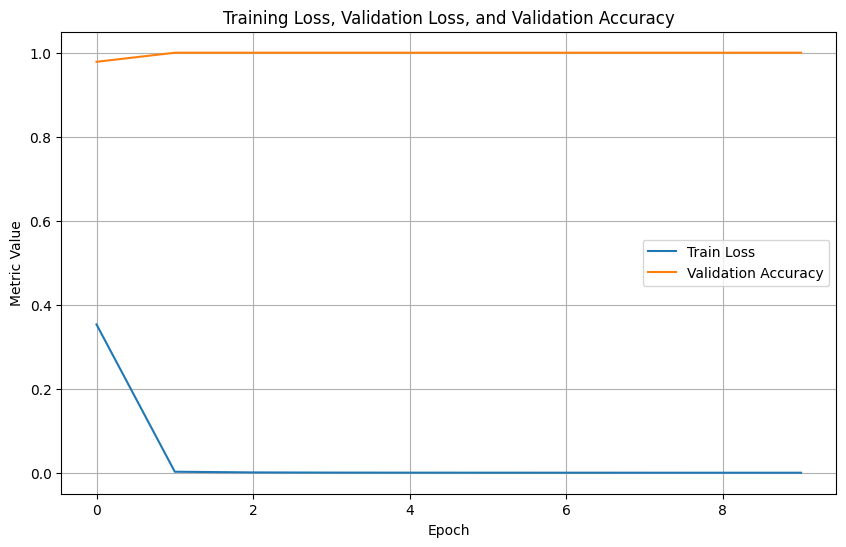

In [ ]:
epochs = range(len(losses))
plt.figure(figsize=(10, 6))
plt.plot(epochs, losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('Training Loss, Validation Loss, and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [70]:

# Define the color palette for the classes (you can adjust these colors as needed)
CLASS_COLORS = [
    [0, 0, 0],       # Class 0: Black (background or empty)
    [255, 0, 0],     # Class 1: Red
    [0, 255, 0],     # Class 2: Green
    [0, 0, 255],     # Class 3: Blue
    [255, 255, 0]    # Class 4: Yellow
]

# Define the transformation for the satellite images and masks
satellite_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

# Load the pre-trained model (ensure that your model is loaded here)
model = SimpleCNN(input_size=(3, 512, 512), num_classes=5)  # Adjust num_classes as per your mask categories
model.load_state_dict(torch.load('satellite_model.pth'))  # Load the trained weights
model.eval()  # Set the model to evaluation mode

# Set up the paths to the satellite images
satellite_folder = './images/satellites'  # Folder containing satellite images
output_folder = './images/val_outputs'  # Folder to save the output images

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Function to map class predictions to the color palette
def apply_class_colors(mask):
    # Create an empty image of the same size but with 3 channels (RGB)
    colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

    # Loop through each class and apply the corresponding color
    for class_idx, color in enumerate(CLASS_COLORS):
        colored_mask[mask == class_idx] = color  # Apply the color to pixels belonging to the class

    return colored_mask

# Function to predict and overlay mask on satellite image
def predict_and_overlay(satellite_image_path, model, transform, output_path):
    # Load the satellite image
    satellite_image = Image.open(satellite_image_path).convert('RGB')

    # Apply transformations
    satellite_tensor = transform(satellite_image).unsqueeze(0)  # Add batch dimension

    # Predict the mask
    with torch.no_grad():
        output = model(satellite_tensor)  # Forward pass
        _, predicted_mask = torch.max(output, 1)  # Get the predicted class

    # Convert the predicted mask to an image
    predicted_mask = predicted_mask.squeeze().cpu().numpy().astype(np.uint8)
    predicted_mask = cv2.resize(predicted_mask, (512, 512), interpolation=cv2.INTER_NEAREST)
    # Apply the class colors to the predicted mask
    colored_mask = apply_class_colors(predicted_mask)

    # Convert the satellite image to a NumPy array for overlay
    satellite_image = np.array(satellite_image)

    # Overlay the colored mask on the satellite image

    overlay = cv2.addWeighted(satellite_image, 0.1, colored_mask, 0.9, 0)

    # Save the overlay image
    result_image = Image.fromarray(overlay)
    result_image.save(output_path)

# Process all images in the satellite folder
satellite_images = sorted(os.listdir(satellite_folder))

for satellite_image_name in satellite_images:
    satellite_image_path = os.path.join(satellite_folder, satellite_image_name)
    output_path = os.path.join(output_folder, f'overlay_{satellite_image_name}.png')
    
    # Predict the mask and save the overlay image
    predict_and_overlay(satellite_image_path, model, satellite_transform, output_path)

print("Predictions and overlays saved successfully!")

Predictions and overlays saved successfully!
